# Acute Mammalian Toxicity

This first data was generated using GenRAPredClassHybrid (class_) and GenRAPredValueHybrid (value_) with the Morgan fingerprint. The goal is to asses their predictive power by calculating ROC AUC scores, but first we need to correctly process the outputs. 

In [2]:
#Import the neighborhood results
print('scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/hazard/hazard_prelim_test.csv references/hazard')

scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/hazard/hazard_prelim_test.csv references/hazard


## Read-in and Cleaning

In [3]:
# Read in the results
import pandas as pd
hazard_df = pd.read_csv('../references/hazard/hazard_prelim_test.csv').set_index('Unnamed: 0')
hazard_df.head(10)

,dsstox_sid,tp_fp0,tp_fp1,tp_fp2,tp_fp3,tp_fp4,tp_fp5,tp_fp6,tp_fp7,tp_fp8,...,Cyclic ketoxime(>C=N-OH) [1 olefin attach],C=N-O-sulfur(aliphatic) [iminoxy] correc,-S-N(-C(=O)-C)-C(=O)-C struct correction,-Sulfur(+4) charged halide-type,Ring rx: S=P(O)(O)O- / 5-mem (2 nitrogen).1,O=P(-O)(-O)-C-OH correction,class_preds,class_proba,value_preds,value_proba
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,DTXSID0060640,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,[0. 0.875 0.125 0. ],1,"[0, 0.12041225608188011, 0.8795877439181199, 0]"
1,DTXSID5025578,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,[0. 0.25 0.375 0.375],2,"[0, 0, 0.12801241137602304, 0.871987588623977]"
2,DTXSID5022308,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,[0.5 0.25 0.25 0. ],1,"[0.7664099649276949, 0.23359003507230514, 0, 0]"
3,DTXSID3059848,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,[0.125 0.75 0.125 0. ],1,"[0, 0.016518905589809618, 0.9834810944101904, 0]"
4,DTXSID3073636,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,[0.125 0.75 0.125 0. ],1,"[0, 0.14660378979070288, 0.8533962102092971, 0]"
5,DTXSID50214453,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,[0. 0.875 0.125 0. ],1,"[0, 0.11780548246690192, 0.8821945175330981, 0]"
6,DTXSID40917426,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,[0.125 0.5 0.125 0.25 ],1,"[0, 0.492373590314338, 0.507626409685662, 0]"
7,DTXSID601031575,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,[0. 0.75 0.125 0.125],1,"[0, 0.32929506953054744, 0.6707049304694526, 0]"
8,DTXSID4073413,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,[0.375 0.625 0. 0. ],1,"[0.6480271279715819, 0.3519728720284181, 0, 0]"


In [4]:
# Read in optimal print results
opt_df = pd.read_csv('../references/hazard/optimum_class_prelim.csv')
opt_df.head(2)

C:\Users\aleary\AppData\Local\Temp\ipykernel_13456\3053322382.py:2: DtypeWarning: Columns (5728) have mixed types. Specify dtype option on import or set low_memory=False.
  opt_df = pd.read_csv('../references/hazard/optimum_class_prelim.csv')


,dsstox_sid,tp_fp0,tp_fp1,tp_fp2,tp_fp3,tp_fp4,tp_fp5,tp_fp6,tp_fp7,tp_fp8,...,=C-(C#N)-C#N [dicyano] correction,Aromatic nitrogen-C-C(=S)-N struct corr.,Cyclic ketoxime(>C=N-OH) [1 olefin attach],C=N-O-sulfur(aliphatic) [iminoxy] correc,-S-N(-C(=O)-C)-C(=O)-C struct correction,-Sulfur(+4) charged halide-type,Ring rx: S=P(O)(O)O- / 5-mem (2 nitrogen).1,O=P(-O)(-O)-C-OH correction,class_preds,class_proba
0,DTXSID0060640,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[1],[0. 0.875 0.125 0. ]
1,DTXSID5025578,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2],[0.125 0.125 0.625 0.125]


In [5]:
#Patch together results that were formatted differently
opt_df.iloc[:6900,-2] = [float(i[1:-1]) for i in opt_df.iloc[:6900, -2]]

In [6]:
#Cut off fingerprints unless needed in analysis
opt_df = opt_df[['class_preds', 'class_proba']]
opt_df.head()

,class_preds,class_proba
0,1.0,[0. 0.875 0.125 0. ]
1,2.0,[0.125 0.125 0.625 0.125]
2,0.0,[0.375 0.375 0.25 0. ]
3,1.0,[0.25 0.75 0. 0. ]
4,1.0,[0. 0.875 0.125 0. ]


In [7]:
#Reformat the value proba lists: assign temporary values that allow you to differentiate
#between a calculated zero and an empty one. Note that value probas were accidentally calculated in 
#reverse in the original code. 
hazard_df['value_proba'] = [i.replace('0.0,','2.0,') for i in hazard_df['value_proba']]
hazard_df['value_proba'] = [i.replace('0.0]','2.0]') for i in hazard_df['value_proba']]
hazard_df['value_proba'] = [i.replace('1]','2]') for i in hazard_df['value_proba']]

In [8]:
#Change proba lists to numerical columns
corrected_proba = {1:[], 2:[], 3:[], 0:[]}
for i in hazard_df['value_proba']:
    pieces = i.split(',')
    i_proba = [pieces[0][1:], pieces[1], pieces[2], pieces[3][:-1]]
    corrected_proba[0].append(float(pieces[0][1:]))
    corrected_proba[1].append(float(pieces[1]))
    corrected_proba[2].append(float(pieces[2]))
    corrected_proba[3].append(float(pieces[3][:-1]))
for j in range(4):
    hazard_df[f'value_proba{j}'] = corrected_proba[j]
hazard_df.head(10)

,dsstox_sid,tp_fp0,tp_fp1,tp_fp2,tp_fp3,tp_fp4,tp_fp5,tp_fp6,tp_fp7,tp_fp8,...,Ring rx: S=P(O)(O)O- / 5-mem (2 nitrogen).1,O=P(-O)(-O)-C-OH correction,class_preds,class_proba,value_preds,value_proba,value_proba0,value_proba1,value_proba2,value_proba3
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,DTXSID0060640,0,0,0,0,0,0,0,0,0,...,0,0,1,[0. 0.875 0.125 0. ],1,"[0, 0.12041225608188011, 0.8795877439181199, 0]",0.000000,0.120412,0.879588,0.000000
1,DTXSID5025578,0,0,0,0,0,0,0,0,0,...,0,0,2,[0. 0.25 0.375 0.375],2,"[0, 0, 0.12801241137602304, 0.871987588623977]",0.000000,0.000000,0.128012,0.871988
2,DTXSID5022308,0,0,0,0,0,0,0,0,0,...,0,0,0,[0.5 0.25 0.25 0. ],1,"[0.7664099649276949, 0.23359003507230514, 0, 0]",0.766410,0.233590,0.000000,0.000000
3,DTXSID3059848,0,0,0,0,0,0,0,0,0,...,0,0,1,[0.125 0.75 0.125 0. ],1,"[0, 0.016518905589809618, 0.9834810944101904, 0]",0.000000,0.016519,0.983481,0.000000
4,DTXSID3073636,0,0,0,0,0,0,0,0,0,...,0,0,1,[0.125 0.75 0.125 0. ],1,"[0, 0.14660378979070288, 0.8533962102092971, 0]",0.000000,0.146604,0.853396,0.000000
5,DTXSID50214453,0,0,0,0,0,0,0,0,0,...,0,0,1,[0. 0.875 0.125 0. ],1,"[0, 0.11780548246690192, 0.8821945175330981, 0]",0.000000,0.117805,0.882195,0.000000
6,DTXSID40917426,0,0,0,0,0,0,0,0,0,...,0,0,1,[0.125 0.5 0.125 0.25 ],1,"[0, 0.492373590314338, 0.507626409685662, 0]",0.000000,0.492374,0.507626,0.000000
7,DTXSID601031575,0,0,0,1,0,0,0,0,0,...,0,0,1,[0. 0.75 0.125 0.125],1,"[0, 0.32929506953054744, 0.6707049304694526, 0]",0.000000,0.329295,0.670705,0.000000
8,DTXSID4073413,0,0,0,0,0,0,0,0,0,...,0,0,1,[0.375 0.625 0. 0. ],1,"[0.6480271279715819, 0.3519728720284181, 0, 0]",0.648027,0.351973,0.000000,0.000000


In [9]:
# Undo the reversed calculations mentioned above
for i in range(4):
    hazard_df[f'value_proba{i}'] = 1 - hazard_df[f'value_proba{i}'] 
hazard_df.loc[:,[f'value_proba{i}' for i in range(4)]] = hazard_df.loc[:,[f'value_proba{i}' for i in range(4)]].replace(float(1), float(0))
hazard_df.loc[:,[f'value_proba{i}' for i in range(4)]] = hazard_df.loc[:,[f'value_proba{i}' for i in range(4)]].replace(float(-1), float(1))

#Dump the original proba column
hazard_df = hazard_df.drop(columns = ['value_proba'])

In [10]:
clean_proba = []
for w in hazard_df['class_proba']:
    cleaner_list = []
    for x in w.split(' '):
        word = ''
        for y in x:
            if y in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '.']:
                word = word + y
        if len(word) > 0:
            cleaner_list.append(float(word))
    clean_proba.append(cleaner_list)

clean_opt_proba = []
for w in opt_df['class_proba']:
    cleaner_list = []
    for x in w.split(' '):
        word = ''
        for y in x:
            if y in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '.']:
                word = word + y
        if len(word) > 0:
            cleaner_list.append(float(word))
    clean_opt_proba.append(cleaner_list)

In [11]:
# Attach the cleaned lists created above
for i in range(4):
    hazard_df[f'class_proba{i}'] = [clean_proba[j][i] for j in range(len(clean_proba))]
    opt_df[f'class_proba{i}'] = [clean_opt_proba[j][i] for j in range(len(clean_opt_proba))]

#Drop the original proba columns
hazard_df = hazard_df.drop(columns = {'class_proba'})
opt_df = opt_df.drop(columns = {'class_proba'})

In [12]:
hazard_df.head(10)

,dsstox_sid,tp_fp0,tp_fp1,tp_fp2,tp_fp3,tp_fp4,tp_fp5,tp_fp6,tp_fp7,tp_fp8,...,class_preds,value_preds,value_proba0,value_proba1,value_proba2,value_proba3,class_proba0,class_proba1,class_proba2,class_proba3
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,DTXSID0060640,0,0,0,0,0,0,0,0,0,...,1,1,0.000000,0.879588,0.120412,0.000000,0.000,0.875,0.125,0.000
1,DTXSID5025578,0,0,0,0,0,0,0,0,0,...,2,2,0.000000,0.000000,0.871988,0.128012,0.000,0.250,0.375,0.375
2,DTXSID5022308,0,0,0,0,0,0,0,0,0,...,0,1,0.233590,0.766410,0.000000,0.000000,0.500,0.250,0.250,0.000
3,DTXSID3059848,0,0,0,0,0,0,0,0,0,...,1,1,0.000000,0.983481,0.016519,0.000000,0.125,0.750,0.125,0.000
4,DTXSID3073636,0,0,0,0,0,0,0,0,0,...,1,1,0.000000,0.853396,0.146604,0.000000,0.125,0.750,0.125,0.000
5,DTXSID50214453,0,0,0,0,0,0,0,0,0,...,1,1,0.000000,0.882195,0.117805,0.000000,0.000,0.875,0.125,0.000
6,DTXSID40917426,0,0,0,0,0,0,0,0,0,...,1,1,0.000000,0.507626,0.492374,0.000000,0.125,0.500,0.125,0.250
7,DTXSID601031575,0,0,0,1,0,0,0,0,0,...,1,1,0.000000,0.670705,0.329295,0.000000,0.000,0.750,0.125,0.125
8,DTXSID4073413,0,0,0,0,0,0,0,0,0,...,1,1,0.351973,0.648027,0.000000,0.000000,0.375,0.625,0.000,0.000


## Analysis

In [13]:
#Bring in original data for reference to train_test_split
import pandas as pd
data = pd.read_csv('../src/data/hazardAcute_Mammalian_Toxicity_Oral_pre-grid-search.csv').set_index('dsstox_sid')

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data.iloc[:, 1:], data.iloc[:, 0], stratify=data.iloc[:,0], random_state = 7108)

In [14]:
# Append true values to test results
hazard_df['y'] = y_test.values

#Create a value proba list of lists for comparison
value_proba = [[hazard_df[f'value_proba{i}'][j] for i in range(4)] for j in range(len(hazard_df))]

In [15]:
from sklearn.metrics import roc_auc_score
import numpy as np

#Compare class vs. value ROC with Morgan prints
roc_auc_score(y_true = hazard_df['y'].values, y_score = np.array([clean_proba])[0], multi_class = 'ovo', average = 'weighted'),roc_auc_score(y_true = hazard_df['y'].values, y_score = np.array([value_proba])[0], multi_class = 'ovo', average = 'weighted')

(0.809108262774978, 0.778299437119585)

In [16]:
pd.DataFrame([{'estimator':'class', 'ROC AUC':roc_auc_score(y_true = hazard_df['y'].values, y_score = np.array([clean_proba])[0], multi_class = 'ovo', average = 'weighted')}, {'estimator':'value', 'ROC AUC':roc_auc_score(y_true = hazard_df['y'].values, y_score = np.array([value_proba])[0], multi_class = 'ovo', average = 'weighted')}])

,estimator,ROC AUC
0,class,0.809108
1,value,0.778299


In [21]:
#Placeholder repeat of the calculation above
roc_auc_score(y_true = hazard_df['y'].values, y_score = np.array([value_proba])[0], multi_class = 'ovo', average = 'weighted')

0.778299437119585

In [20]:
#Alternate, one vs. rest weighting
roc_auc_score(y_true = hazard_df['y'].values, y_score = np.array([clean_opt_proba])[0], multi_class = 'ovr', average = 'weighted')

0.8028392611489447

In [18]:
#Renaming columns for consistency and distinguishability
opt_df = opt_df.rename(columns={'class_preds':'opt_preds', 'class_proba0':'opt_proba0', 'class_proba1':'opt_proba1', \
                       'class_proba2':'opt_proba2', 'class_proba3':'opt_proba3'})

In [19]:
#Combine all of the results into one df
hazard_df = pd.concat([hazard_df, opt_df], axis = 1)

In [20]:
#Calculate A,B,C, and D for McNemar Test
a = 0
b = 0
c = 0
d = 0
for index, row in hazard_df.iterrows():
    if row['class_preds'] == row['y']:
        if row['opt_preds'] == row['y']:
            a += 1
        else:
            b += 1
    elif row['opt_preds'] == row['y']:
        c += 1
    else:
        d += 1
a,b,c,d

(5023, 368, 470, 2122)

In [21]:
#Calculate McNemar Chi^2 value
chi = (abs(b-c)-1)**2 / (b+c)
chi

12.173031026252984

In [22]:
from sklearn.metrics import balanced_accuracy_score

#Compare accuracies between Optimal and Morgan predictions (Opt First)
balanced_accuracy_score(y_true = hazard_df['y'], y_pred=hazard_df['opt_preds'].astype('int'), adjusted=False),balanced_accuracy_score(y_true = hazard_df['y'], y_pred=hazard_df['class_preds'], adjusted=False) 

(0.5437170207732717, 0.5220124854942678)

In [23]:
#Check balance of classes in data
data['score'].value_counts()

score
1    18646
0     6514
2     5066
3     1705
Name: count, dtype: int64

In [24]:
from sklearn.metrics import confusion_matrix

#Check the confusion matrix for all classifications
pd.DataFrame(confusion_matrix(y_true = hazard_df['y'], y_pred=hazard_df['opt_preds'].astype('int')), index = ['L','M','H','VH'], columns = ['predicted L', 'predicted M', 'predicted H', 'predicted VH'])


,predicted L,predicted M,predicted H,predicted VH
L,892,706,27,4
M,452,3970,211,29
H,55,687,462,62
VH,24,134,93,175


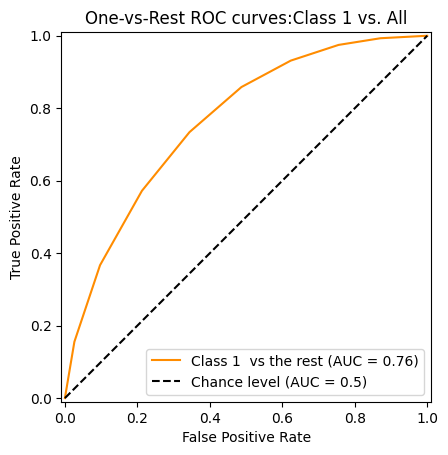

In [25]:
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
y_onehot_test.shape

import matplotlib.pyplot as plt

from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay.from_predictions(
    y_onehot_test[:,1],
    hazard_df['class_proba1'],
    name=f"Class 1  vs the rest",
    color="darkorange",
    plot_chance_level=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves:Class 1 vs. All",
)

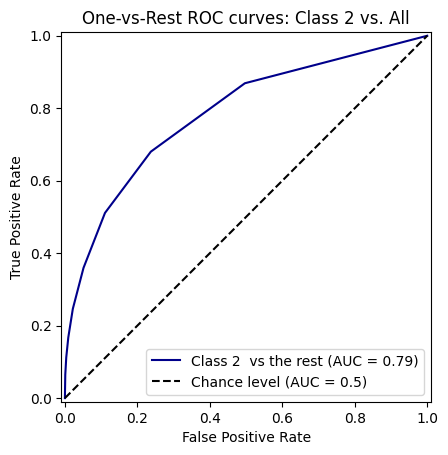

In [26]:
display = RocCurveDisplay.from_predictions(
    y_onehot_test[:,2],
    hazard_df['class_proba2'],
    name=f"Class 2  vs the rest",
    color="darkblue",
    plot_chance_level=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves: Class 2 vs. All",
)

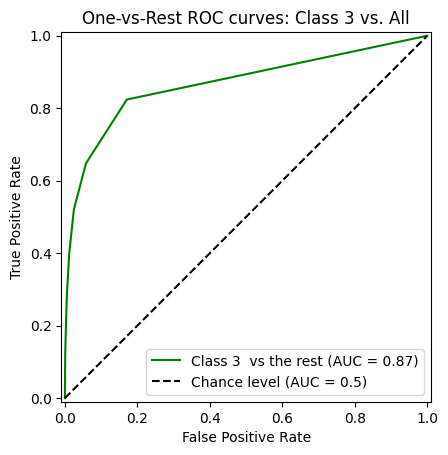

In [27]:
display = RocCurveDisplay.from_predictions(
    y_onehot_test[:,3],
    hazard_df['class_proba3'],
    name=f"Class 3  vs the rest",
    color="green",
    plot_chance_level=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves: Class 3 vs. All",
)

In [35]:
proba_list = list(hazard_df['class_proba3'].unique())
proba_list.sort()
for proba in proba_list:
    limited_df = hazard_df.loc[hazard_df['y']==3]
    count = len(limited_df.loc[limited_df['class_proba3']>=proba])
    percent = count/len(limited_df)
    neg_set = hazard_df.loc[hazard_df['y'] != 3]
    bad_count = len(neg_set.loc[neg_set['class_proba3']>=proba])
    bad_cent = bad_count/len(neg_set)
    print(f'Proba: {proba}, TP Rate: {percent}, % FP Caught: {bad_cent}')

Proba: 0.0, TP Rate: 1.0, % FP Caught: 1.0
Proba: 0.125, TP Rate: 0.823943661971831, % FP Caught: 0.17096731507211857
Proba: 0.25, TP Rate: 0.647887323943662, % FP Caught: 0.05822416302765648
Proba: 0.375, TP Rate: 0.5211267605633803, % FP Caught: 0.024877596929998677
Proba: 0.5, TP Rate: 0.39906103286384975, % FP Caught: 0.011909487892020643
Proba: 0.625, TP Rate: 0.284037558685446, % FP Caught: 0.005425433373031626
Proba: 0.75, TP Rate: 0.19483568075117372, % FP Caught: 0.00277888050813815
Proba: 0.875, TP Rate: 0.1267605633802817, % FP Caught: 0.0009262935027127167
Proba: 1.0, TP Rate: 0.07746478873239436, % FP Caught: 0.0005293105729786953


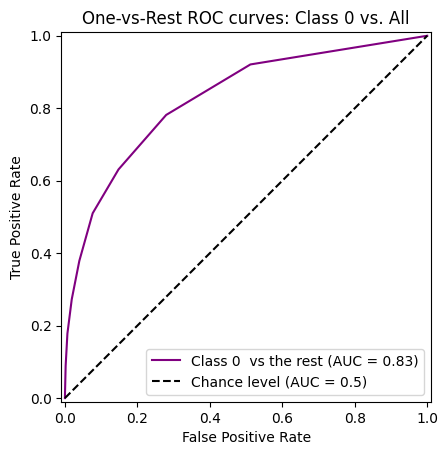

In [30]:
display = RocCurveDisplay.from_predictions(
    y_onehot_test[:,0],
    hazard_df['class_proba0'],
    name=f"Class 0  vs the rest",
    color="purple",
    plot_chance_level=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves: Class 0 vs. All",
)

In [36]:
proba_list = list(hazard_df['class_proba0'].unique())
proba_list.sort()
for proba in proba_list:
    limited_df = hazard_df.loc[hazard_df['y']==0]
    count = len(limited_df.loc[limited_df['class_proba0']>=proba])
    percent = count/len(limited_df)
    neg_set = hazard_df.loc[hazard_df['y'] != 0]
    bad_count = len(neg_set.loc[neg_set['class_proba0']>=proba])
    bad_cent = bad_count/len(neg_set)
    print(f'Proba: {proba}, TP Rate: {percent}, % FP Caught: {bad_cent}')

Proba: 0.0, TP Rate: 1.0, % FP Caught: 1.0
Proba: 0.125, TP Rate: 0.9208103130755064, % FP Caught: 0.5119609694680516
Proba: 0.25, TP Rate: 0.7814610190300798, % FP Caught: 0.279508970727101
Proba: 0.375, TP Rate: 0.6310620012277471, % FP Caught: 0.1479383065785332
Proba: 0.5, TP Rate: 0.5101289134438306, % FP Caught: 0.0766446333018571
Proba: 0.625, TP Rate: 0.3787599754450583, % FP Caught: 0.039817437834435004
Proba: 0.75, TP Rate: 0.27255985267034993, % FP Caught: 0.018885741265344664
Proba: 0.875, TP Rate: 0.1780233271945979, % FP Caught: 0.006924771797293044
Proba: 1.0, TP Rate: 0.08901166359729895, % FP Caught: 0.002045955303745672


In [41]:
def probaPlot(class_number):
    not_threes = {'index':[], 'proba':[]}
    threes = {'index':[], 'proba':[]}
    for x in range(len(hazard_df)):
        if hazard_df.iloc[x].loc['y'] == class_number:
            threes['index'].append(x)
            threes['proba'].append(hazard_df.iloc[x].loc[f'class_proba{class_number}'])
        else: 
            not_threes['index'].append(x)
            not_threes['proba'].append(hazard_df.iloc[x].loc[f'class_proba{class_number}'])

    bottom = np.zeros(20)
    bins = np.array([i for i in np.arange(0,1.05, 0.05)])

    plt.subplots()
    plt.hist(not_threes['proba'], color = 'tab:red', bottom=bottom, bins = bins, label = 'In class')

    i = 0
    for bin in np.arange(0,1.0,0.05):
        weight_count = 0
        for item in not_threes['proba']:
            if item >= bin and item < bin + 0.05:
                weight_count += 1
        bottom[i] += weight_count
        if i <= 20:
            i += 1

    plt.hist(threes['proba'], color = 'tab:green', bottom=bottom, bins = bins, label = 'Not in class')

    plt.xlabel('Proba')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

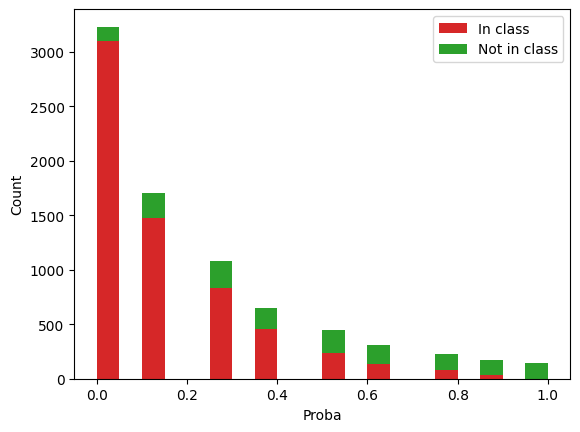

In [42]:
probaPlot(0)

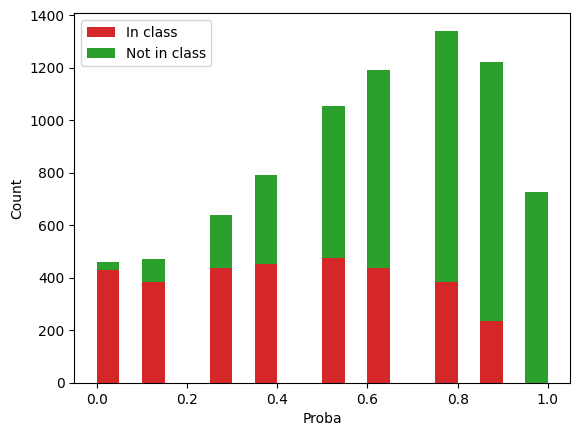

In [43]:
probaPlot(1)

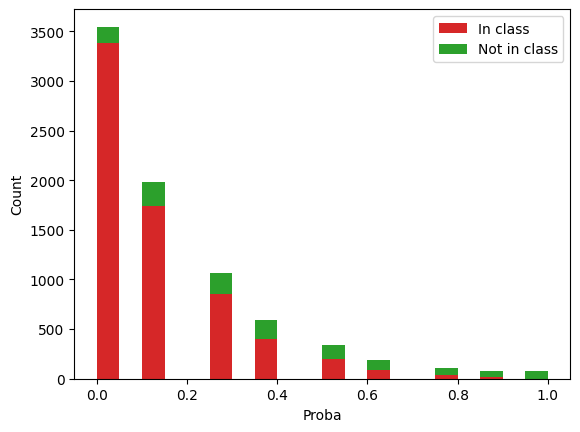

In [44]:
probaPlot(2)

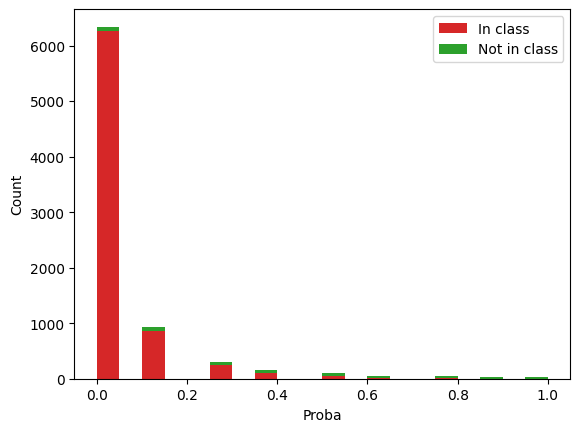

In [45]:
probaPlot(3)

# Carcinogenicity Tests

## Read-in and Cleaning

In [2]:
#Import the neighborhood results
print('scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/hazard/morgan_complete_carcinogenicity.csv references/hazard/')
print('scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/hazard/optimum_class_carcinogenicity.csv references/hazard/')

scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/hazard/morgan_complete_carcinogenicity.csv references/hazard/
scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/hazard/optimum_class_carcinogenicity.csv references/hazard/


In [56]:
import pandas as pd
carc_mor_df = pd.read_csv('../references/hazard/morgan_complete_carcinogenicity.csv')
carc_opt_df = pd.read_csv('../references/hazard/optimum_class_carcinogenicity.csv')
carc_mor_df.head(10)

,dsstox_sid,tp_fp0,tp_fp1,tp_fp2,tp_fp3,tp_fp4,tp_fp5,tp_fp6,tp_fp7,tp_fp8,...,-CCl3 [aliphatic attach],Halogen [Nitrogen attach],As(=O),-N=C=S,Sn=O,-N=S=O,class_preds,class_proba,value_preds,value_proba
0,DTXSID50193815,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,[0. 0. 1. 0.],2,"[0, 0, 0.0, 0]"
1,DTXSID1049350,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,[0. 0. 0.875 0.125],2,"[0, 0, 0.11667619903586912, 0.8833238009641309]"
2,DTXSID10972289,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,[0. 0. 1. 0.],2,"[0, 0, 0.0, 0]"
3,DTXSID80873976,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,[0. 0. 1. 0.],2,"[0, 0, 0.0, 0]"
4,DTXSID00208685,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,[0. 0. 1. 0.],2,"[0, 0, 0.0, 0]"
5,DTXSID201020205,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,[0. 0. 1. 0.],2,"[0, 0, 0.0, 0]"
6,DTXSID8021147,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,[0. 0. 0.875 0.125],2,"[0, 0, 0.1329574858511875, 0.8670425141488125]"
7,DTXSID30167574,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,[0. 0. 0.5 0.5],2,"[0, 0, 0.47938707499400923, 0.5206129250059908]"
8,DTXSID0023907,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,3,[0. 0. 0.125 0.875],3,"[0, 0, 0.8821959468205178, 0.11780405317948217]"
9,DTXSID1063485,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,[0. 0. 1. 0.],2,"[0, 0, 0.0, 0]"


In [57]:
#Cut off fingerprints unless needed in analysis
carc_opt_df = carc_opt_df[['class_preds', 'class_proba']]
carc_opt_df.head()

,class_preds,class_proba
0,2,[0. 0. 1. 0.]
1,2,[0. 0. 1. 0.]
2,2,[0. 0. 1. 0.]
3,2,[0. 0. 1. 0.]
4,2,[0. 0. 1. 0.]


In [58]:
# Reformat the value proba lists
carc_mor_df['value_proba'] = [i.replace('0.0,','2.0,') for i in carc_mor_df['value_proba']]
carc_mor_df['value_proba'] = [i.replace('0.0]','2.0]') for i in carc_mor_df['value_proba']]
carc_mor_df['value_proba'] = [i.replace('1]','2]') for i in carc_mor_df['value_proba']]

In [59]:
#Change proba lists to numerical columns
corrected_proba = {1:[], 2:[], 3:[], 0:[]}
for i in carc_mor_df['value_proba']:
    pieces = i.split(',')
    i_proba = [pieces[0][1:], pieces[1], pieces[2], pieces[3][:-1]]
    corrected_proba[0].append(float(pieces[0][1:]))
    corrected_proba[1].append(float(pieces[1]))
    corrected_proba[2].append(float(pieces[2]))
    corrected_proba[3].append(float(pieces[3][:-1]))
for j in range(4):
    carc_mor_df[f'value_proba{j}'] = corrected_proba[j]

In [60]:
# Undo the reversed calculations mentioned above
for i in range(4):
    carc_mor_df[f'value_proba{i}'] = 1 - carc_mor_df[f'value_proba{i}'] 
carc_mor_df.loc[:,[f'value_proba{i}' for i in range(4)]] = carc_mor_df.loc[:,[f'value_proba{i}' for i in range(4)]].replace(float(1), float(0))
carc_mor_df.loc[:,[f'value_proba{i}' for i in range(4)]] = carc_mor_df.loc[:,[f'value_proba{i}' for i in range(4)]].replace(float(-1), float(1))

In [61]:
#Dump the original proba column
carc_mor_df = carc_mor_df.drop(columns = ['value_proba'])

In [62]:
# Clean the class proba lists for both Morgan and Optimal results
clean_proba = []
for w in carc_mor_df['class_proba']:
    cleaner_list = []
    for x in w.split(' '):
        word = ''
        for y in x:
            if y in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '.']:
                word = word + y
        if len(word) > 0:
            cleaner_list.append(float(word))
    clean_proba.append(cleaner_list)

clean_opt_proba = []
for w in carc_opt_df['class_proba']:
    cleaner_list = []
    for x in w.split(' '):
        word = ''
        for y in x:
            if y in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '.']:
                word = word + y
        if len(word) > 0:
            cleaner_list.append(float(word))
    clean_opt_proba.append(cleaner_list)

In [63]:
# Attach the cleaned lists created above
for i in range(4):
    carc_mor_df[f'class_proba{i}'] = [clean_proba[j][i] for j in range(len(clean_proba))]
    carc_opt_df[f'class_proba{i}'] = [clean_opt_proba[j][i] for j in range(len(clean_opt_proba))]

#Drop the original proba columns
carc_mor_df = carc_mor_df.drop(columns = {'class_proba'})
carc_opt_df = carc_opt_df.drop(columns = {'class_proba'})

## Analysis

In [64]:
#Bring in original data for reference to train_test_split
data = pd.read_csv('../src/data/hazard_Carcinogenicity_pre-grid-search.csv').set_index('dsstox_sid')

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data.iloc[:, 2:], data.iloc[:, 0], stratify=data.iloc[:,0], random_state = 8411)

In [65]:
#Append true y values to the test result data frames
carc_mor_df['y'] = y_test.values

#Grab the value proba as a list of lists for comparisons
value_proba = [[carc_mor_df[f'value_proba{i}'][j] for i in range(4)] for j in range(len(carc_mor_df))]

In [66]:
from sklearn.metrics import roc_auc_score
import numpy as np

#Check class vs. value ROC, both with Morgan prints
roc_auc_score(y_true = carc_mor_df['y'].values, y_score = np.array([clean_proba])[0], multi_class = 'ovo', average = 'weighted'),roc_auc_score(y_true = carc_mor_df['y'].values, y_score = np.array([value_proba])[0], multi_class = 'ovo', average = 'weighted')

(0.7835068959728787, 0.7219591949746121)

In [67]:
#Renaming columns for consistency and distinguishability after concatenation
carc_opt_df = carc_opt_df.rename(columns={'class_preds':'opt_preds', 'class_proba0':'opt_proba0', 'class_proba1':'opt_proba1', \
                       'class_proba2':'opt_proba2', 'class_proba3':'opt_proba3'})

In [68]:
#Combine all of the results into one df
carcinogenicity_df = pd.concat([carc_mor_df, carc_opt_df], axis = 1)

In [69]:
#Calculate A,B,C, and D for McNemar Test
a = 0
b = 0
c = 0
d = 0
for index, row in carcinogenicity_df.iterrows():
    if row['class_preds'] == row['y']:
        if row['opt_preds'] == row['y']:
            a += 1
        else:
            b += 1
    elif row['opt_preds'] == row['y']:
        c += 1
    else:
        d += 1
a,b,c,d

(755, 20, 18, 104)

In [70]:
#Calculate McNemar Chi^2 value
chi = (abs(b-c)-1)**2 / (b+c)
chi

0.02631578947368421

In [71]:
from sklearn.metrics import balanced_accuracy_score

#Compare accuracies between Optimal and Morgan predictions (Opt First)
balanced_accuracy_score(y_true = carcinogenicity_df['y'], y_pred=carcinogenicity_df['opt_preds'].astype('int'), adjusted=False),balanced_accuracy_score(y_true = carcinogenicity_df['y'], y_pred=carcinogenicity_df['class_preds'], adjusted=False) 

(0.35286848604395693, 0.3468173927337166)

In [73]:
#Check balance of classes in data as w hole
data['score'].value_counts()

score
2    2978
3     494
0     110
1       4
Name: count, dtype: int64

Note: With only 4 members of class 1 carcinogenicity, a test set will only have 1 member of class 1. This means the estimator has no chance of correctly classing that member with the voting system used. 

In [78]:
from sklearn.metrics import confusion_matrix

#Check the confusion matrix for all classifications
confusion_matrix(y_true = carcinogenicity_df['y'], y_pred=carcinogenicity_df['opt_preds'].astype('int'))


array([[  2,   0,  23,   2],
       [  0,   0,   1,   0],
       [  2,   0, 726,  17],
       [  3,   0,  76,  45]], dtype=int64)

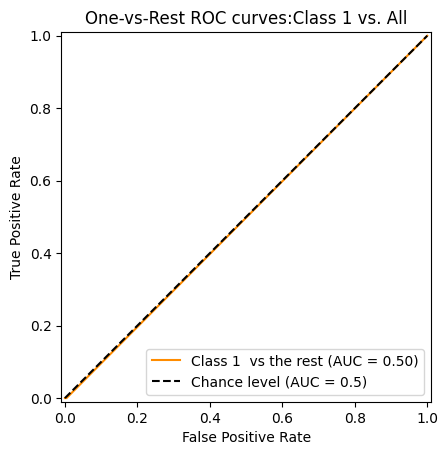

In [79]:
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
y_onehot_test.shape

import matplotlib.pyplot as plt

from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay.from_predictions(
    y_onehot_test[:,1],
    carcinogenicity_df['class_proba1'],
    name=f"Class 1  vs the rest",
    color="darkorange",
    plot_chance_level=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves:Class 1 vs. All",
)

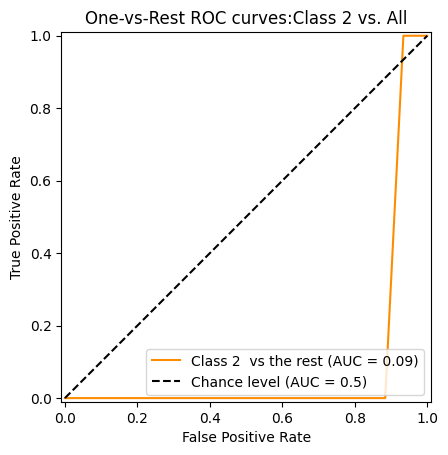

In [80]:
display = RocCurveDisplay.from_predictions(
    y_onehot_test[:,1],
    carcinogenicity_df['class_proba2'],
    name=f"Class 2  vs the rest",
    color="darkorange",
    plot_chance_level=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves:Class 2 vs. All",
)

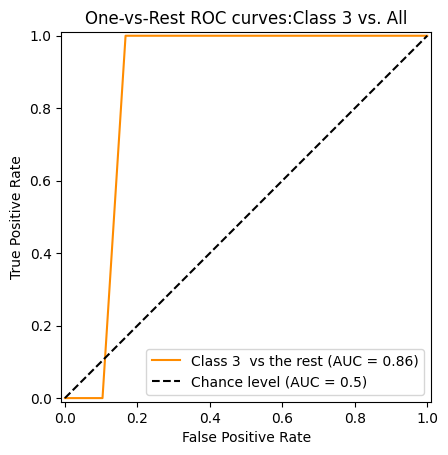

In [81]:
display = RocCurveDisplay.from_predictions(
    y_onehot_test[:,1],
    carcinogenicity_df['class_proba3'],
    name=f"Class 3  vs the rest",
    color="darkorange",
    plot_chance_level=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves:Class 3 vs. All",
)

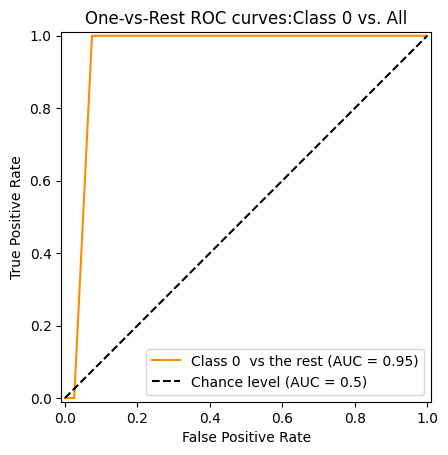

In [82]:
display = RocCurveDisplay.from_predictions(
    y_onehot_test[:,1],
    carcinogenicity_df['class_proba0'],
    name=f"Class 0  vs the rest",
    color="darkorange",
    plot_chance_level=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves:Class 0 vs. All",
)

In [83]:
#Create a function for viewing a graph of how different proba levels separate data points
def probaPlot(class_number):
    not_threes = {'index':[], 'proba':[]}
    threes = {'index':[], 'proba':[]}
    for x in range(len(carcinogenicity_df)):
        if carcinogenicity_df.iloc[x].loc['y'] == class_number:
            threes['index'].append(x)
            threes['proba'].append(carcinogenicity_df.iloc[x].loc[f'class_proba{class_number}'])
        else: 
            not_threes['index'].append(x)
            not_threes['proba'].append(carcinogenicity_df.iloc[x].loc[f'class_proba{class_number}'])

    bottom = np.zeros(20)
    bins = np.array([i for i in np.arange(0,1.05, 0.05)])

    plt.subplots()
    plt.hist(not_threes['proba'], color = 'tab:red', bottom=bottom, bins = bins, label = 'In class')

    i = 0
    for bin in np.arange(0,1.0,0.05):
        weight_count = 0
        for item in not_threes['proba']:
            if item >= bin and item < bin + 0.05:
                weight_count += 1
        bottom[i] += weight_count
        if i <= 20:
            i += 1

    plt.hist(threes['proba'], color = 'tab:green', bottom=bottom, bins = bins, label = 'Not in class')

    plt.xlabel('Proba')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

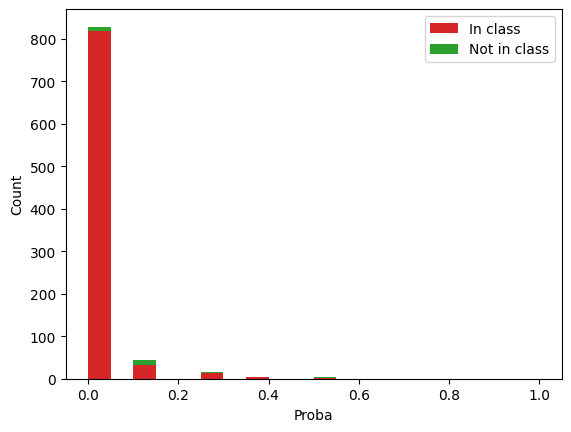

In [84]:
probaPlot(0)

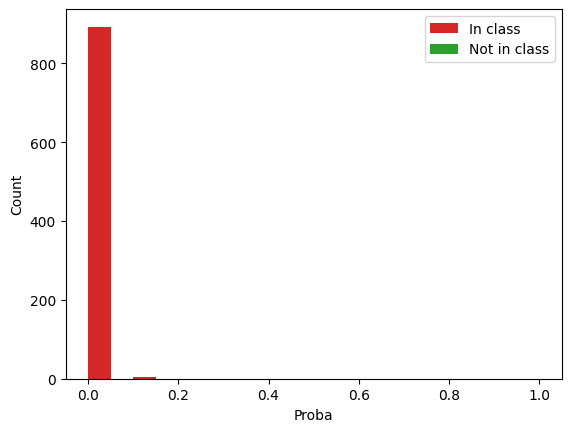

In [85]:
probaPlot(1)

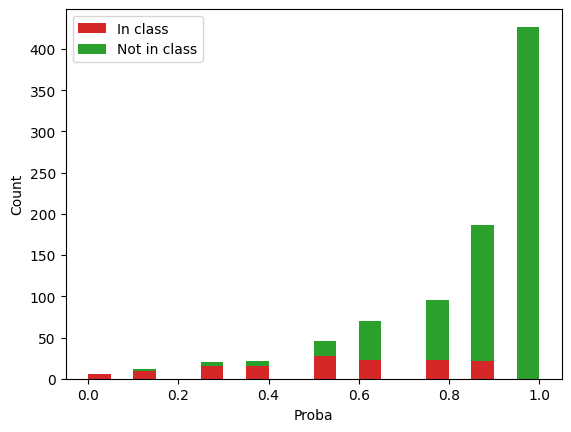

In [86]:
probaPlot(2)

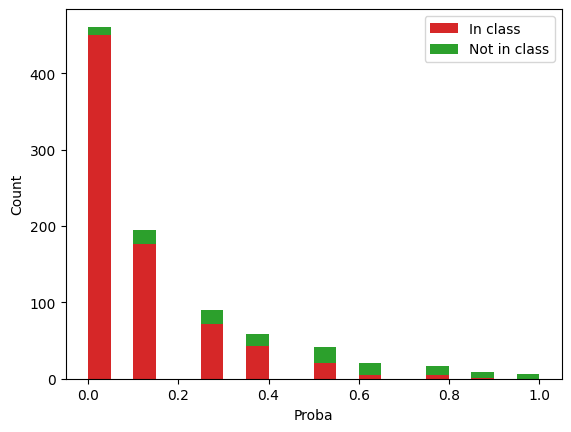

In [87]:
probaPlot(3)